# Plotting Quality of Approximation

This section of the notebook shows graphs for the datasets on which the clustering benchmark has been run

The plots use a closest-point assignment, rather than the clusters produced by the algorithms, as this best measures the quality of the centers, in my opinion.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [466]:
sns.set_palette("colorblind")

# Clustering Data

In [38]:
df_symmetric_clustering = pd.read_csv('clustering-benchmark-data/clustering_results_symmetric-unbiased.csv', header=None, names=['Algorithm', 'k', 'cost'])
df_symmetric_clustering = df_symmetric_clustering.assign(Dataset=pd.Series(["Symmetric" for i in range(df_symmetric_clustering.shape[0])]).values)

df_census_clustering = pd.read_csv('clustering-benchmark-data/clustering_results_USCensus1990-unbiased.csv', header=None, names=['Algorithm', 'k', 'cost'])
df_census_clustering = df_census_clustering.assign(Dataset=pd.Series(["Census" for i in range(df_census_clustering.shape[0])]).values)

df_song_clustering = pd.read_csv('clustering-benchmark-data/clustering_results_YearPredictionMSD-unbiased.csv', header=None, names=['Algorithm', 'k', 'cost'])
df_song_clustering = df_song_clustering.assign(Dataset=pd.Series(["Song" for i in range(df_song_clustering.shape[0])]).values)

df_kdd_train = pd.read_csv('clustering-benchmark-data/clustering_results_bio_train-unbiased.csv', header=None, names=['Algorithm', 'k', 'cost'])
df_kdd_train = df_kdd_train.assign(Dataset=pd.Series(["KDD" for i in range(df_kdd_train.shape[0])]).values)

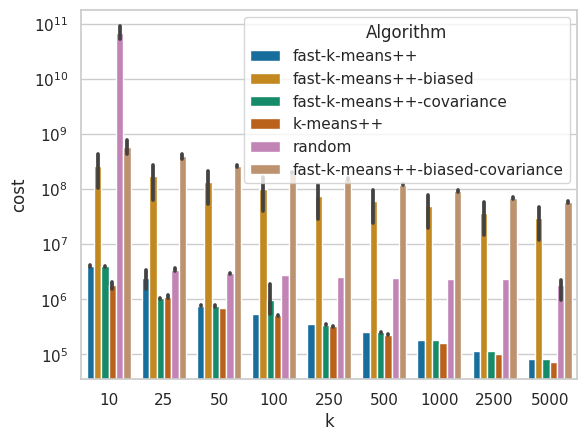

In [467]:
df_symmetric_biased = pd.read_csv('clustering-benchmark-data/clustering_results_symmetric-biased-indep.csv', header=None, names=['Algorithm', 'k', 'cost'])
df_symmetric_biased = df_census_biased.assign(Dataset=pd.Series(["Symmetric" for i in range(df_census_biased.shape[0])]).values)

df_symmetric_cov = pd.read_csv('clustering-benchmark-data/clustering_results_symmetric-cov.csv', header=None, names=['Algorithm', 'k', 'cost'])
df_symmetric_cov = df_census_cov.assign(Dataset=pd.Series(["Symmetric" for i in range(df_census_cov.shape[0])]).values)

df_symmetric_plus = pd.concat([df_symmetric_clustering, df_symmetric_biased, df_symmetric_cov])

plot = sns.barplot(data=df_symmetric_plus, x='k', y='cost', hue='Algorithm')
plt.yscale('log')
plt.savefig('plots/clustering-plot-census.pdf', transparent=True, dpi=300)

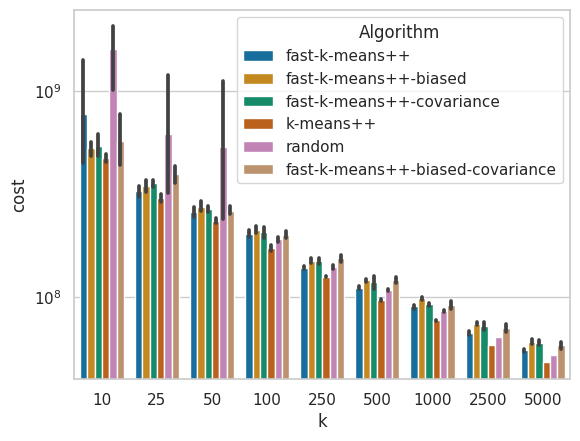

In [468]:
df_census_biased = pd.read_csv('clustering-benchmark-data/clustering_results_USCensus1990-biased-indep.csv', header=None, names=['Algorithm', 'k', 'cost'])
df_census_biased = df_census_biased.assign(Dataset=pd.Series(["Census" for i in range(df_census_biased.shape[0])]).values)

df_census_cov = pd.read_csv('clustering-benchmark-data/clustering_results_USCensus1990-cov.csv', header=None, names=['Algorithm', 'k', 'cost'])
df_census_cov = df_census_cov.assign(Dataset=pd.Series(["Census" for i in range(df_census_cov.shape[0])]).values)


df_census_plus = pd.concat([df_census_clustering, df_census_biased, df_census_cov])

plot = sns.barplot(data=df_census_plus, x='k', y='cost', hue='Algorithm')
plt.yscale('log')
plt.savefig('plots/clustering-plot-census.pdf', transparent=True, dpi=300)

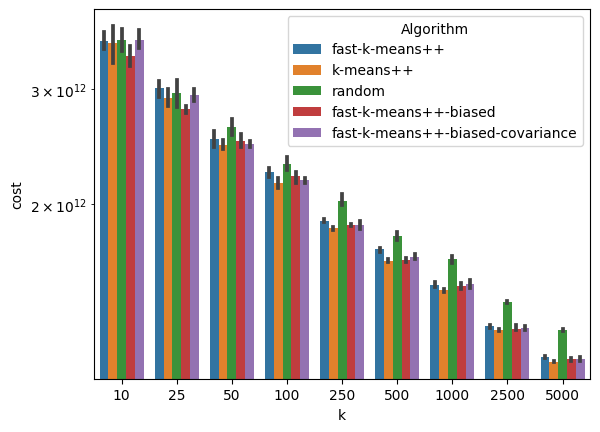

In [34]:
df_song_biased = pd.read_csv('clustering-benchmark-data/clustering_results_YearPredictionMSD-biased-indep.csv', header=None, names=['Algorithm', 'k', 'cost'])
df_song_biased = df_song_biased.assign(Dataset=pd.Series(["Song" for i in range(df_song_biased.shape[0])]).values)

df_song_cov = pd.read_csv('clustering-benchmark-data/clustering_results_YearPredictionMSD-cov.csv', header=None, names=['Algorithm', 'k', 'cost'])
df_song_cov = df_song_cov.assign(Dataset=pd.Series(["Song" for i in range(df_song_cov.shape[0])]).values)

df_song_plus = pd.concat([df_song_clustering, df_song_biased, df_song_cov])

plot = sns.barplot(data=df_song_plus, x='k', y='cost', hue='Algorithm')
plt.yscale('log')
plt.savefig('plots/clustering-plot-song.pdf', transparent=True, dpi=300)

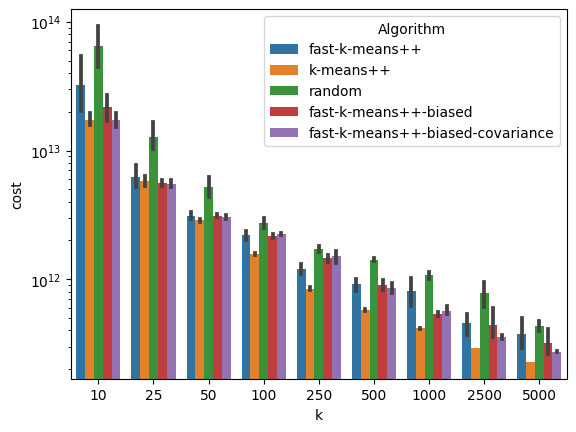

In [37]:
df_kdd_train_biased = pd.read_csv('clustering-benchmark-data/clustering_results_bio_train-biased-indep.csv', header=None, names=['Algorithm', 'k', 'cost'])
df_kdd_train_biased = df_kdd_train_biased.assign(Dataset=pd.Series(["KDD" for i in range(df_kdd_train_biased.shape[0])]).values)

df_kdd_train_cov = pd.read_csv('clustering-benchmark-data/clustering_results_bio_train-cov.csv', header=None, names=['Algorithm', 'k', 'cost'])
df_kdd_train_cov = df_kdd_train_cov.assign(Dataset=pd.Series(["KDD" for i in range(df_kdd_train_cov.shape[0])]).values)

df_kdd_plus = pd.concat([df_kdd_train, df_kdd_train_biased, df_kdd_train_cov])

plot = sns.barplot(data=df_kdd_plus, x='k', y='cost', hue='Algorithm')
plt.yscale('log')
plt.savefig('plots/clustering-plot-kdd-train.pdf', transparent=True, dpi=300)

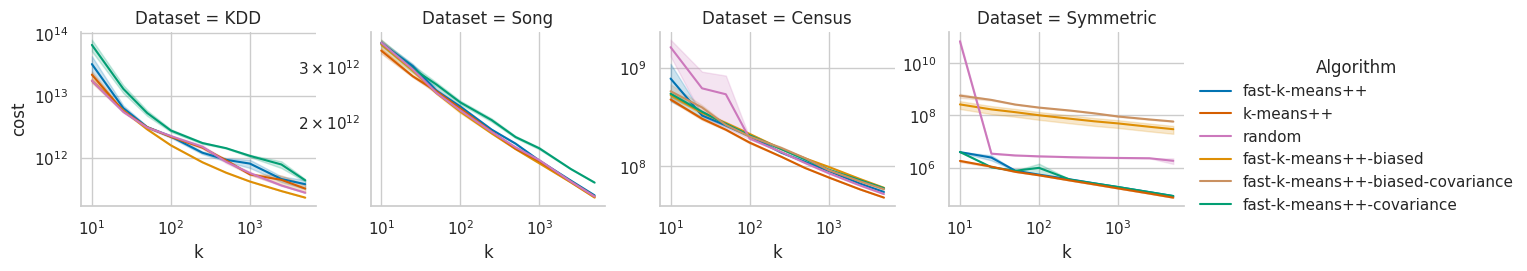

In [469]:
sns.set_theme(style="whitegrid", palette="colorblind")

df_clustering = pd.concat([df_kdd_plus, df_song_plus, df_census_plus, df_symmetric_plus])

plot = sns.FacetGrid(df_clustering, col="Dataset", sharey = False)
plot.map_dataframe(sns.lineplot, x = "k", y = "cost", hue = "Algorithm", errorbar = "se")

plot.add_legend(title="Algorithm")
plot.set(xscale="log", yscale="log")

fig = plot.fig
fig.savefig("plots/clustering-plot.pdf", transparent=True, dpi=300)

# Cluster Plot (latest) + Time Table


In [565]:
df_symmetric_clustering = pd.read_csv('clustering-benchmark-closest/clustering_results_symmetric.csv', header=None, names=['Algorithm', 'k', 'cost'])
df_symmetric_clustering = df_symmetric_clustering.assign(Dataset=pd.Series(["Symmetric" for i in range(df_symmetric_clustering.shape[0])]).values)

df_census_clustering = pd.read_csv('clustering-benchmark-closest/clustering_results_USCensus1990.csv', header=None, names=['Algorithm', 'k', 'cost'])
df_census_clustering = df_census_clustering.assign(Dataset=pd.Series(["Census" for i in range(df_census_clustering.shape[0])]).values)

df_song_clustering = pd.read_csv('clustering-benchmark-closest/clustering_results_YearPredictionMSD.csv', header=None, names=['Algorithm', 'k', 'cost'])
df_song_clustering = df_song_clustering.assign(Dataset=pd.Series(["Song" for i in range(df_song_clustering.shape[0])]).values)

df_kdd_clustering = pd.read_csv('clustering-benchmark-closest/clustering_results_bio_train.csv', header=None, names=['Algorithm', 'k', 'cost'])
df_kdd_clustering = df_kdd_clustering.assign(Dataset=pd.Series(["KDD" for i in range(df_kdd_clustering.shape[0])]).values)

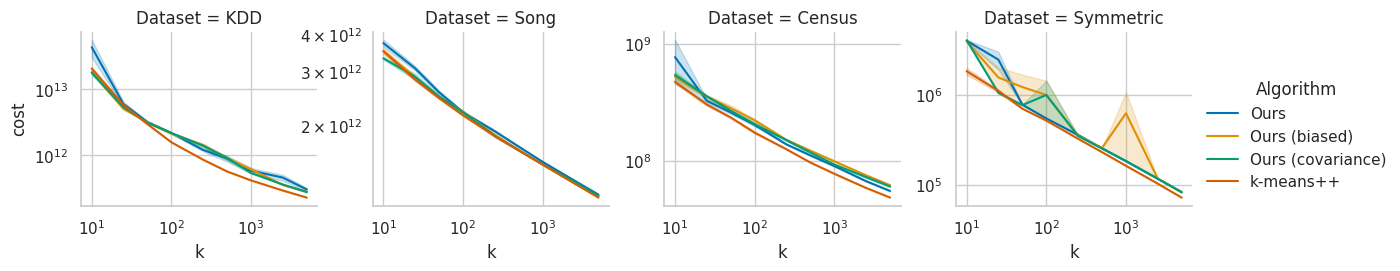

In [566]:
sns.set_theme(style="whitegrid", palette="colorblind")

df_clustering = pd.concat([df_kdd_clustering, df_song_clustering, df_census_clustering, df_symmetric_clustering])
df_clustering = df_clustering[df_clustering["Algorithm"] != "Random"]

plot = sns.FacetGrid(df_clustering, col="Dataset", sharey = False)
plot.map_dataframe(sns.lineplot, x = "k", y = "cost", hue = "Algorithm", errorbar = "se")

plot.add_legend(title="Algorithm")
plot.set(xscale="log", yscale="log")

fig = plot.fig
fig.savefig("plots/clustering-plot.pdf", transparent=True, dpi=300)

# Running Time (Absolute)

In [46]:
import csv

def read_cluster_time_results(filename):
    with open(filename, newline='') as csvfile:
        data = csv.reader(csvfile, delimiter=",")
        #df = pd.DataFrame({}, columns=["Algorithm", "Dataset", "Coreset Size", "Centers", "Cost"])
        df_dict = {
            "Algorithm": [],
            "Dataset": [],
            #"Size": [],
            "Centers": [],
            "Time": [],
        }
        for row in data:
            [name, time] = row
            name = name.split("/")[-1]
            parts = name.split("-")
            df_dict["Algorithm"].append(parts[0])
            df_dict["Dataset"].append(parts[1])
            #df_dict["Size"].append(int(parts[3]))
            df_dict["Centers"].append(int(parts[2]))
            df_dict["Time"].append(float(time))
        
        return pd.DataFrame.from_dict(df_dict)

In [176]:
df_bio_time = read_cluster_time_results("cluster-timings-bio_train.csv")
df_song_time = read_cluster_time_results("cluster-timings-YearPredictionMSD.csv")
df_census_time = read_cluster_time_results("cluster-timings-USCensus1990.csv")
df_symmetric_time = read_cluster_time_results("cluster-timings-symmetric.csv")

df_full_time = pd.concat([df_bio_time, df_song_time, df_census_time, df_symmetric_time])

In [181]:
df_full_time.groupby(["Dataset", "Algorithm", "Centers"]).mean().round(decimals=2).unstack()

Time                             \
Centers                                      10       25       50       100    
Dataset           Algorithm                                                    
USCensus1990      fastkmeans++             520.19   530.71   548.36   555.16   
                  fastkmeans++biased      1637.84  1652.73  1738.48  1747.58   
                  fastkmeans++covariance  3008.84  3221.11  3321.79  3372.64   
YearPredictionMSD fastkmeans++             110.05   111.33   113.92   113.66   
                  fastkmeans++biased       442.16   447.45   448.34   448.53   
                  fastkmeans++covariance  1207.88  1187.86  1185.44  1167.65   
bio_train         fastkmeans++              30.12    28.52    29.38    28.46   
                  fastkmeans++biased        73.21    74.08    73.22    75.57   
                  fastkmeans++covariance   174.75   178.16   175.03   179.00   
symmetric         fastkmeans++              31.87    32.91    31.77    32.68   
                  fastkmeans++biased        30.20    29.93    30.35    30.28   
                  fastkmeans++covariance    34.53    32.95    34.21    34.44   

                                                                              \
Centers                                      250      500      1000     2500   
Dataset           Algorithm                                                    
USCensus1990      fastkmeans++             564.25   575.35   556.23   577.00   
                  fastkmeans++biased      1748.95  1768.74  1750.01  1767.57   
                  fastkmeans++covariance  3336.67  3507.42  3618.97  3629.07   
YearPredictionMSD fastkmeans++             116.07   116.50   119.35   124.13   
                  fastkmeans++biased       450.80   452.19   456.82   463.17   
                  fastkmeans++covariance  1206.96  1258.66  1255.39  1292.00   
bio_train         fastkmeans++              30.45    29.76    28.82    30.49   
                  fastkmeans++biased        78.68    76.08    74.82    76.57   
                  fastkmeans++covariance   183.17   180.97   181.01   182.18   
symmetric         fastkmeans++              34.03    33.41    32.55    32.52   
                  fastkmeans++biased        31.60    30.47    31.26    31.85   
                  fastkmeans++covariance    35.84    35.05    35.83    35.38   

                                                   
Centers                                      5000  
Dataset           Algorithm                        
USCensus1990      fastkmeans++             606.65  
                  fastkmeans++biased      1795.09  
                  fastkmeans++covariance  3626.64  
YearPredictionMSD fastkmeans++             131.53  
                  fastkmeans++biased       473.31  
                  fastkmeans++covariance  1261.70  
bio_train         fastkmeans++              32.58  
                  fastkmeans++biased        76.06  
                  fastkmeans++covariance   186.84  
symmetric         fastkmeans++              33.84  
                  fastkmeans++biased        32.38  
                  fastkmeans++covariance    35.15

# Assignments produced by the algorithm

In [562]:
df_symmetric_clustering = pd.read_csv('clustering-assignments-100-runs/clustering_results_symmetric.csv', header=None, names=['Algorithm', 'k', 'cost'])
df_symmetric_clustering = df_symmetric_clustering.assign(Dataset=pd.Series(["Gaussian" for i in range(df_symmetric_clustering.shape[0])]).values)
df_symmetric_kmpp = pd.read_csv('clustering-benchmark-data/symmetric_kmpp.csv', header=None, names=['Algorithm', 'k', 'cost'])
df_symmetric_kmpp = df_symmetric_kmpp.assign(Dataset=pd.Series(["Gaussian" for i in range(df_symmetric_kmpp.shape[0])]).values)

df_symmetric_clustering = pd.concat([df_symmetric_clustering, df_symmetric_kmpp])

df_census_clustering = pd.read_csv('clustering-assignments-100-runs/clustering_results_USCensus1990.csv', header=None, names=['Algorithm', 'k', 'cost'])
df_census_clustering = df_census_clustering.assign(Dataset=pd.Series(["Census" for i in range(df_census_clustering.shape[0])]).values)
df_census_kmpp = pd.read_csv('clustering-benchmark-data/USCensus1990_kmpp.csv', header=None, names=['Algorithm', 'k', 'cost'])
df_census_kmpp = df_census_kmpp.assign(Dataset=pd.Series(["Census" for i in range(df_census_kmpp.shape[0])]).values)

df_census_clustering = pd.concat([df_census_clustering, df_census_kmpp])


df_song_clustering = pd.read_csv('clustering-assignments-100-runs/clustering_results_YearPredictionMSD.csv', header=None, names=['Algorithm', 'k', 'cost'])
df_song_clustering = df_song_clustering.assign(Dataset=pd.Series(["Song" for i in range(df_song_clustering.shape[0])]).values)
df_song_kmpp = pd.read_csv('clustering-benchmark-data/YearPredictionMSD_kmpp.csv', header=None, names=['Algorithm', 'k', 'cost'])
df_song_kmpp = df_song_kmpp.assign(Dataset=pd.Series(["Song" for i in range(df_song_kmpp.shape[0])]).values)

df_song_clustering = pd.concat([df_song_clustering, df_song_kmpp])


df_kdd_clustering = pd.read_csv('clustering-assignments-100-runs/clustering_results_bio_train.csv', header=None, names=['Algorithm', 'k', 'cost'])
df_kdd_clustering = df_kdd_clustering.assign(Dataset=pd.Series(["KDD" for i in range(df_kdd_clustering.shape[0])]).values)
df_kdd_kmpp = pd.read_csv('clustering-benchmark-data/bio_train_kmpp.csv', header=None, names=['Algorithm', 'k', 'cost'])
df_kdd_kmpp = df_kdd_kmpp.assign(Dataset=pd.Series(["KDD" for i in range(df_kdd_kmpp.shape[0])]).values)

df_kdd_clustering = pd.concat([df_kdd_clustering, df_kdd_kmpp])


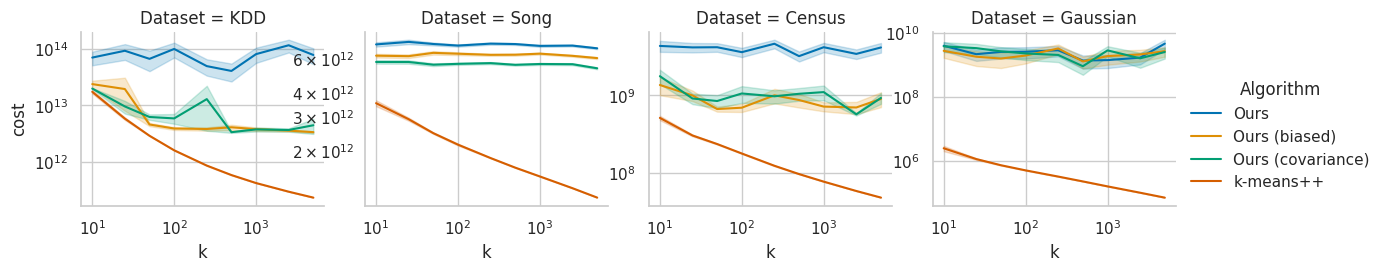

In [563]:
sns.set_theme(style="whitegrid", palette="colorblind")

df_clustering = pd.concat([df_kdd_clustering, df_song_clustering, df_census_clustering, df_symmetric_clustering])

plot = sns.FacetGrid(df_clustering[df_clustering["k"] < 10000], col="Dataset", sharey = False)
plot.map_dataframe(sns.lineplot, x = "k", y = "cost", hue = "Algorithm", errorbar = "se")

plot.add_legend(title="Algorithm")
plot.set(xscale="log", yscale="log")

fig = plot.fig
fig.savefig("plots/clustering-plot-assignment.pdf", transparent=True, dpi=300)

In [502]:
# Average factor by which the costs are higher

alg_names = ["fast-k-means++", "k-means++"]
dataset_names = ["KDD", "Song", "Census", "Gaussian"]

df_list = [df_clustering[df_clustering["Algorithm"] == i] for i in alg_names]
df_means = [i.groupby(["Dataset", "Algorithm", "k"]).mean().to_numpy() for i in df_list]
rel_means = [i / df_means[-1] for i in df_means]

df_list_rel = []
for (df, rel) in zip(df_list, rel_means):
    df = (df.groupby(["Dataset", "Algorithm", "k"]).mean())
    df["cost"] = rel
    df_list_rel.append(df)
    
df_list_rel[0].groupby("Dataset").mean()

,cost
Dataset,
Census,36.034967
Gaussian,12989.414667
KDD,129.908279
Song,3.872431


# Coreset Evaluation

In [85]:
from sklearn.cluster import k_means

In [86]:
def load_coreset(filename):
    csv = np.genfromtxt(filename, delimiter=",")
    n, d = csv.shape
    [points, weights] = np.split(csv, [d-1], axis=1)
    return points, weights

In [87]:
def score_centers(filename, centers):
    dataset = np.genfromtxt(filename, delimiter=",")
    distances = np.square(np.linalg.norm(dataset - centers[0], axis=1))
    
    for center in centers[1:]:
        distances = np.minimum(distances, np.square(np.linalg.norm(dataset - center, axis=1)))
        
    return np.sum(distances)

In [88]:
def evaluate_coreset(filename, dataset, num_centers):
    points, weights = load_coreset(filename)
    weights = weights.flatten()
    centroids, assignments, cost = k_means(points, num_centers, 
                                           sample_weight=weights, n_init='auto')
    
    return score_centers(dataset, centroids)

In [89]:
def cluster_coreset_and_export(filename, num_centers, num_runs = 5):
    points, weights = load_coreset(filename)
    weights = weights.flatten()
    for i in range(num_runs):
        centroids, _, _ = k_means(points, num_centers, 
                                           sample_weight=weights, n_init='auto')
    
        stem = filename.split('.')[0]
        stem = stem.split('/')[-1]
        np.savetxt("clustered-coresets/" + stem + f"-clustered-{i}.csv", centroids, delimiter=',')

In [107]:
from os import walk

coreset_files = []
for (dirpath, dirnames, filenames) in walk("coresets/"):
    coreset_files.extend(filenames)
    break

In [108]:
counter = 1
for filename in coreset_files:
    print(f"{filename}, ({counter} of {len(coreset_files)})")
    counter = counter + 1
    num_clusters = int(filename.split("-")[2])
    num_samples = int(filename.split("-")[3])
    if (num_samples >= num_clusters):
        cluster_coreset_and_export("coresets/" + filename, num_clusters)

fast-bio_train-10-1457-3.csv
1
fast-YearPredictionMSD-1000-2576-3.csv
2
fast-USCensus1990-1000-2458-4.csv
3
fast-bio_train-1000-7287-2.csv
4
fast-YearPredictionMSD-1000-1288-2.csv
5
fast-YearPredictionMSD-10-515-2.csv
6
fast-YearPredictionMSD-1000-5153-1.csv
7
fast-symmetric-100-1200-4.csv
8
fast-USCensus1990-100-2458-2.csv
9
fast-bio_train-10-364-1.csv
10
fast-symmetric-10-12000-4.csv
11
fast-USCensus1990-10-122914-4.csv
12
fast-symmetric-1000-240-3.csv
13
fast-USCensus1990-1000-245828-3.csv
14
fast-symmetric-100-12000-4.csv
15
fast-symmetric-1000-24000-2.csv
16
fast-USCensus1990-10-122914-2.csv
17
fast-symmetric-10-600-5.csv
18
fast-symmetric-10-12000-2.csv
19
fast-YearPredictionMSD-1000-515-1.csv
20
fast-USCensus1990-10-24582-2.csv
21
fast-YearPredictionMSD-10-2576-1.csv
22
fast-USCensus1990-1000-122914-2.csv
23
fast-bio_train-1000-145-4.csv
24
fast-USCensus1990-1000-12291-3.csv
25
fast-symmetric-100-600-5.csv
26
fast-USCensus1990-1000-122914-4.csv
27
fast-YearPredictionMSD-10-1288-

fast-USCensus1990-10-6145-2.csv
227
fast-bio_train-10-145-3.csv
228
fast-bio_train-10-1457-4.csv
229
fast-YearPredictionMSD-100-515-1.csv
230
fast-bio_train-100-3643-2.csv
231
fast-symmetric-10-240-5.csv
232
fast-symmetric-100-600-4.csv
233
fast-YearPredictionMSD-1000-5153-4.csv
234
fast-USCensus1990-1000-24582-3.csv
235
fast-symmetric-100-24000-5.csv
236
fast-bio_train-100-145-2.csv
237
fast-USCensus1990-10-6145-1.csv
238
fast-YearPredictionMSD-100-51534-4.csv
239
fast-USCensus1990-100-24582-5.csv
240
fast-YearPredictionMSD-1000-25767-5.csv
241
fast-symmetric-1000-600-1.csv
242
fast-symmetric-10-2400-5.csv
243
fast-symmetric-1000-1200-1.csv
244
fast-bio_train-1000-364-2.csv
245
fast-USCensus1990-10-12291-4.csv
246
fast-symmetric-100-12000-3.csv
247
fast-YearPredictionMSD-100-5153-3.csv
248
fast-YearPredictionMSD-1000-25767-2.csv
249
fast-symmetric-100-240-1.csv
250
fast-USCensus1990-100-24582-3.csv
251
fast-USCensus1990-10-24582-4.csv
252
fast-USCensus1990-1000-6145-4.csv
253
fast-USC

In [93]:
def cluster_dataset(filename):
    dataset = np.genfromtxt(filename, delimiter=",")
    costs = []
    centroids = []
    
    for num_centers in [10, 100, 1000]:
        avg_cost = 0.0
        for i in range(5):
            print(num_centers)
            centroids_, _, cost = k_means(dataset, num_centers, n_init='auto')
            avg_cost = avg_cost + cost
            centroids.append(centroids_)
        costs.append(avg_cost / 5.0)
    
    return (costs, centroids)
    

In [ ]:
clusters = {}

clusters["bio_train"] = cluster_dataset("data/bio_train.dat")
clusters["USCensus"] = cluster_dataset("data/USCensus1990.txt")
clusters["YearPrediction"] = cluster_dataset("data/YearPredictionMSD.txt")
clusters["symmetric"] = cluster_dataset("data/symmetric.csv")

In [170]:
clusters["symmetric"][0][0]

943972.6633796107

In [413]:
clusters

df_base = pd.DataFrame.from_dict({
    "Algorithm": ["Baseline" for i in range(4 * 3 * 5)],
    "Dataset": ["KDD" for i in range(3 * 5)] + ["Census" for i in range(3 * 5)] + ["Song" for i in range(3 * 5)] + ["Gaussian" for i in range(3 * 5)],
    "Size": ([145, 364, 728, 1475, 14575] * 3) + ([2458, 5000, 10000, 50000, 245828] * 3) + ([515, 1100, 10000, 50000, 51534] * 3) + ([240, 500, 1200, 15000, 24000] * 3),
    "k": ([10] * 5 + [100] * 5 + [1000] * 5) * 4 ,
    "Cost": ([clusters["bio_train"][0][0]] * 5)
    + ([clusters["bio_train"][0][1]] * 5)
    + ([clusters["bio_train"][0][2]] * 5)
    + ([clusters["USCensus"][0][0]] * 5)
    + ([clusters["USCensus"][0][1]] * 5)
    + ([clusters["USCensus"][0][2]] * 5)
    + ([clusters["YearPrediction"][0][0]] * 5)
    + ([clusters["YearPrediction"][0][1]] * 5)
    + ([clusters["YearPrediction"][0][2]] * 5)
    + ([clusters["symmetric"][0][0]] * 5)
    + ([clusters["symmetric"][0][1]] * 5)
    + ([clusters["symmetric"][0][2]] * 5),
})

In [415]:
import csv

dmap = { "USCensus1990": "Census", 
         "YearPredictionMSD": "Song",
         "symmetric": "Gaussian",
         "bio_train": "KDD",
       }

def dataset_map(name):
    return dmap[name]

def read_cluster_results(filename):
    with open(filename, newline='') as csvfile:
        data = csv.reader(csvfile, delimiter=",")
        #df = pd.DataFrame({}, columns=["Algorithm", "Dataset", "Coreset Size", "Centers", "Cost"])
        df_dict = {
            "Algorithm": [],
            "Dataset": [],
            "Size": [],
            "k": [],
            "Cost": [],
        }
        for row in data:
            [name, cost] = row
            name = name.split("/")[-1]
            parts = name.split("-")
            #print(parts)
            df_dict["Algorithm"].append(parts[0])
            df_dict["Dataset"].append(dataset_map(parts[1]))
            df_dict["Size"].append(int(parts[3]))
            df_dict["k"].append(int(parts[2]))
            df_dict["Cost"].append(float(cost))
        
        return pd.DataFrame.from_dict(df_dict)

In [416]:
df_bio = read_cluster_results("coreset-fast-data/cluster-costs-bio_train.csv")
df_bio = pd.concat([df_bio, read_cluster_results("coreset-baseline-data/bio_train_baseline.csv")])

df_song = read_cluster_results("coreset-fast-data/cluster-costs-YearPredictionMSD.csv")
df_song = pd.concat([df_song, read_cluster_results("coreset-baseline-data/YearPredictionMSD_baseline.csv")])

df_census = read_cluster_results("coreset-fast-data/cluster-costs-USCensus1990.csv")
df_census = pd.concat([df_census, read_cluster_results("coreset-baseline-data/USCensus1990_baseline.csv")])

df_symmetric = read_cluster_results("coreset-fast-data/cluster-costs-symmetric.csv")
df_symmetric = pd.concat([df_symmetric, read_cluster_results("coreset-baseline-data/symmetric_baseline.csv")])


df_full = pd.concat([df_bio, df_song, df_census, df_symmetric, df_base])

In [524]:
df_bio = pd.concat([#read_cluster_results("coreset-fast-data/cluster-costs-bio_train.csv"), 
                    read_cluster_results("coreset-baseline-data/bio_train_baseline.csv"),
                    read_cluster_results("coreset-benchmark-sunday/cluster-costs-bio_train.csv"),
                    read_cluster_results("coreset-benchmark-with-covariance/cluster-costs-bio_train.csv"),
                    read_cluster_results("coreset-fast-data/cluster-costs-bio_train.csv")
                   ])

df_song = pd.concat([#read_cluster_results("coreset-fast-data/cluster-costs-YearPredictionMSD.csv"), 
                    read_cluster_results("coreset-baseline-data/YearPredictionMSD_baseline.csv"),
                    read_cluster_results("coreset-benchmark-sunday/cluster-costs-YearPredictionMSD.csv"),
                    read_cluster_results("coreset-benchmark-with-covariance/cluster-costs-YearPredictionMSD.csv"),
                    read_cluster_results("coreset-fast-data/cluster-costs-YearPredictionMSD.csv")
                   ])

df_census = pd.concat([#read_cluster_results("coreset-fast-data/cluster-costs-USCensus1990.csv"), 
                    read_cluster_results("coreset-baseline-data/USCensus1990_baseline.csv"),
                    read_cluster_results("coreset-benchmark-sunday/cluster-costs-USCensus1990.csv"),
                    read_cluster_results("coreset-benchmark-with-covariance/cluster-costs-USCensus1990.csv"),
                    read_cluster_results("coreset-fast-data/cluster-costs-USCensus1990.csv")

                   ])

df_symmetric= pd.concat([#read_cluster_results("coreset-fast-data/cluster-costs-symmetric.csv"), 
                    read_cluster_results("coreset-baseline-data/symmetric_baseline.csv"),
                    read_cluster_results("coreset-benchmark-sunday/cluster-costs-symmetric.csv"),
                    read_cluster_results("coreset-benchmark-with-covariance/cluster-costs-symmetric.csv"),
                    read_cluster_results("coreset-fast-data/cluster-costs-symmetric.csv")

                   ])


df_full = pd.concat([df_bio, df_song, df_census, df_symmetric, df_base])

In [518]:
df_symmetric[df_symmetric["Algorithm"] == "Ours"]

,Algorithm,Dataset,Size,k,Cost
475,Ours,Gaussian,1200,10,959955.159615
476,Ours,Gaussian,1200,10,959370.691211
477,Ours,Gaussian,1200,10,959473.669988
478,Ours,Gaussian,1200,10,959780.002990
479,Ours,Gaussian,1200,10,960945.760458
...,...,...,...,...,...
945,Ours,Gaussian,6000,1000,158240.565053
946,Ours,Gaussian,6000,1000,158649.979622
947,Ours,Gaussian,6000,1000,158602.433679
948,Ours,Gaussian,6000,1000,158922.992459


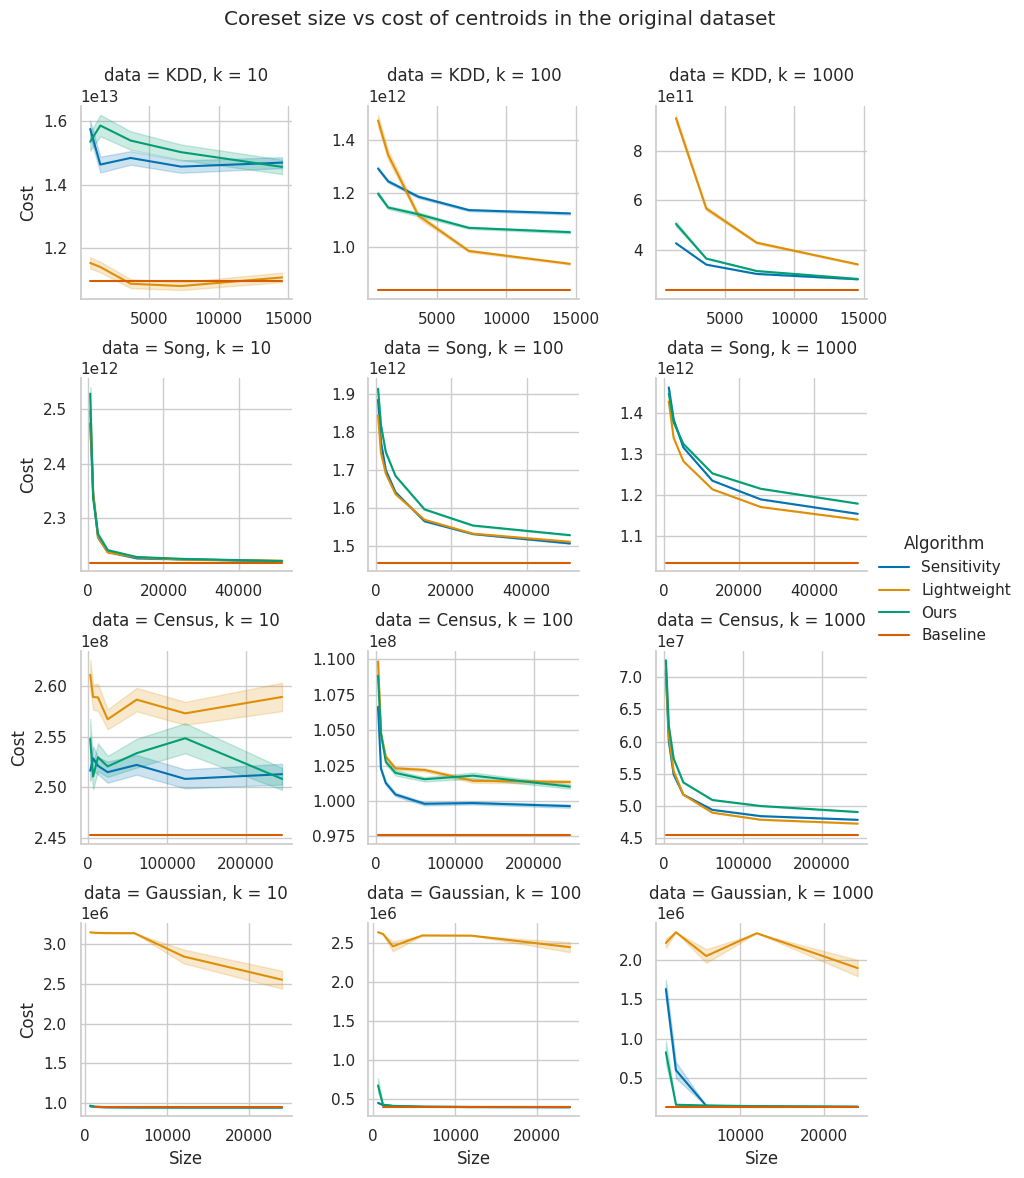

In [418]:
import seaborn as sns
sns.set_theme(style="whitegrid", palette="colorblind")

plot = sns.FacetGrid(data=df_full[(df_full["Size"] > 500)], hue="Algorithm", col = "k", row="Dataset", sharey=False, sharex=False, margin_titles=False)

plot.map(sns.lineplot, "Size", "Cost", errorbar="se")
plot.add_legend(title="Algorithm")
plot.set_titles("data = {row_name}, k = {col_name}")

plot.fig.subplots_adjust(top=0.9)
plot.fig.suptitle("Coreset size vs cost of centroids in the original dataset")

fig = plot.fig
fig.savefig("plots/coreset-plot.png", transparent=True, dpi=300)

In [525]:
# make the dataframes relative
bio_size = 145751
song_size = 515345
census_size = 2458285
symmetric_size = 240005

bio_cost_10 = clusters["bio_train"][0][0]
bio_cost_100 = clusters["bio_train"][0][1]
bio_cost_1000 = clusters["bio_train"][0][2]

song_cost_10 = clusters["YearPrediction"][0][0]
song_cost_100 = clusters["YearPrediction"][0][1]
song_cost_1000 = clusters["YearPrediction"][0][2]

census_cost_10 = clusters["USCensus"][0][0]
census_cost_100 = clusters["USCensus"][0][1]
census_cost_1000 = clusters["USCensus"][0][2]

symmetric_cost_10 = clusters["symmetric"][0][0]
symmetric_cost_100 = clusters["symmetric"][0][1]
symmetric_cost_1000 = clusters["symmetric"][0][2]


df_rel_base = pd.DataFrame.from_dict({
    "Algorithm": ["Baseline" for i in range(4 * 3 * 5)],
    "Dataset": ["KDD" for i in range(3 * 5)] + ["Census" for i in range(3 * 5)] + ["Song" for i in range(3 * 5)] + ["Gaussian" for i in range(3 * 5)],
    "Size": ([0.001, 0.0025, 0.005, 0.01, 0.1] * 3 * 4),
    "k": ([10] * 5 + [100] * 5 + [1000] * 5) * 4 ,
    "Cost": [1.0 for i in range(4 * 3 * 5)],
})

df_rel_bio = read_cluster_results("coreset-fast-data/cluster-costs-bio_train.csv")
df_rel_bio = pd.concat([df_rel_bio, read_cluster_results("coreset-baseline-data/bio_train_baseline.csv")])
df_rel_bio = pd.concat([#read_cluster_results("coreset-fast-data/cluster-costs-bio_train.csv"), 
                    read_cluster_results("coreset-baseline-data/bio_train_baseline.csv"),
                    read_cluster_results("coreset-benchmark-sunday/cluster-costs-bio_train.csv"),
                    read_cluster_results("coreset-benchmark-with-covariance/cluster-costs-bio_train.csv"),
                    read_cluster_results("coreset-fast-data/cluster-costs-bio_train.csv")
                   ])


#df_rel_bio["Cost"] = df_rel_bio["Cost"] / df_rel_bio_base
df_rel_bio["Size"] = df_rel_bio["Size"] / bio_size
df_rel_bio.loc[df_rel_bio["k"]==10, "Cost"] /= bio_cost_10
df_rel_bio.loc[df_rel_bio["k"]==100, "Cost"] /= bio_cost_100
df_rel_bio.loc[df_rel_bio["k"]==1000, "Cost"] /= bio_cost_1000


df_rel_song = read_cluster_results("coreset-fast-data/cluster-costs-YearPredictionMSD.csv")
df_rel_song = pd.concat([df_rel_song, read_cluster_results("coreset-baseline-data/YearPredictionMSD_baseline.csv")])
df_rel_song = pd.concat([#read_cluster_results("coreset-fast-data/cluster-costs-YearPredictionMSD.csv"), 
                    read_cluster_results("coreset-baseline-data/YearPredictionMSD_baseline.csv"),
                    read_cluster_results("coreset-benchmark-sunday/cluster-costs-YearPredictionMSD.csv"),
                    read_cluster_results("coreset-benchmark-with-covariance/cluster-costs-YearPredictionMSD.csv"),
                    read_cluster_results("coreset-fast-data/cluster-costs-YearPredictionMSD.csv")
                   ])

##df_rel_song["Cost"] = df_rel_song["Cost"] / df_rel_song_base
df_rel_song["Size"] = df_rel_song["Size"] / song_size
df_rel_song.loc[df_rel_song["k"]==10, "Cost"] /= song_cost_10
df_rel_song.loc[df_rel_song["k"]==100, "Cost"] /= song_cost_100
df_rel_song.loc[df_rel_song["k"]==1000, "Cost"] /= song_cost_1000


df_rel_census = read_cluster_results("coreset-fast-data/cluster-costs-USCensus1990.csv")
df_rel_census = pd.concat([df_rel_census, read_cluster_results("coreset-baseline-data/USCensus1990_baseline.csv")])
df_rel_census = pd.concat([#read_cluster_results("coreset-fast-data/cluster-costs-USCensus1990.csv"), 
                    read_cluster_results("coreset-baseline-data/USCensus1990_baseline.csv"),
                    read_cluster_results("coreset-benchmark-sunday/cluster-costs-USCensus1990.csv"),
                    read_cluster_results("coreset-benchmark-with-covariance/cluster-costs-USCensus1990.csv"),
                    read_cluster_results("coreset-fast-data/cluster-costs-USCensus1990.csv")
                   ])

##df_rel_census["Cost"] = df_rel_census["Cost"] / df_rel_census_base
df_rel_census["Size"] = df_rel_census["Size"] / census_size
df_rel_census.loc[df_rel_census["k"]==10, "Cost"] /= census_cost_10
df_rel_census.loc[df_rel_census["k"]==100, "Cost"] /= census_cost_100
df_rel_census.loc[df_rel_census["k"]==1000, "Cost"] /= census_cost_1000


df_rel_symmetric = read_cluster_results("coreset-fast-data/cluster-costs-symmetric.csv")
df_rel_symmetric = pd.concat([df_rel_symmetric, read_cluster_results("coreset-baseline-data/symmetric_baseline.csv")])
df_rel_symmetric= pd.concat([#read_cluster_results("coreset-fast-data/cluster-costs-symmetric.csv"), 
                    read_cluster_results("coreset-baseline-data/symmetric_baseline.csv"),
                    read_cluster_results("coreset-benchmark-sunday/cluster-costs-symmetric.csv"),
                    read_cluster_results("coreset-benchmark-with-covariance/cluster-costs-symmetric.csv"),
                    read_cluster_results("coreset-fast-data/cluster-costs-symmetric.csv")
                   ])


#df_rel_symmetric["Cost"] = df_rel_symmetric["Cost"] / df_rel_symmetric_base
df_rel_symmetric["Size"] = df_rel_symmetric["Size"] / symmetric_size
df_rel_symmetric.loc[df_rel_symmetric["k"]==10, "Cost"] /= symmetric_cost_10
df_rel_symmetric.loc[df_rel_symmetric["k"]==100, "Cost"] /= symmetric_cost_100
df_rel_symmetric.loc[df_rel_symmetric["k"]==1000, "Cost"] /= symmetric_cost_1000


df_rel_full = pd.concat([df_rel_bio, df_rel_song, df_rel_census, df_rel_symmetric, df_rel_base])#, df_rel_base, df_rel_symmetric])

In [557]:
df_rel_full = df_rel_full.rename(columns={"Cost": "Relative Cost", "Size": "Relative Size"})

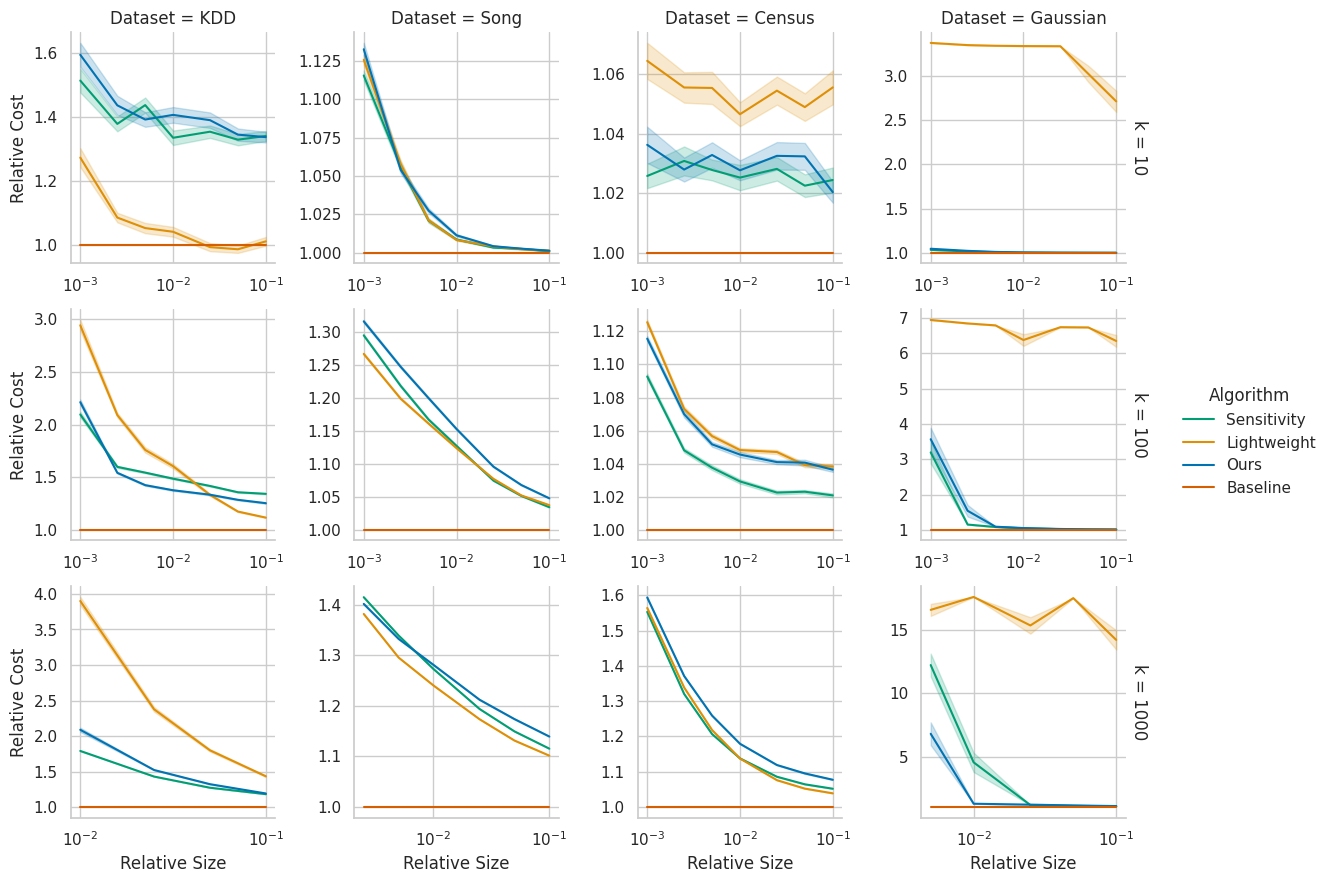

In [558]:
import seaborn as sns
sns.set_theme(style="whitegrid", palette="colorblind")

#df_rel_full.rename(columns={"Cost": "Relative Cost", "Size": "Relative Size"})

plot = sns.FacetGrid(data=df_rel_full[df_full["Size"]>= df_full["k"]], hue="Algorithm", palette=[(0.00784313725490196, 0.6196078431372549, 0.45098039215686275), (0.8705882352941177, 0.5607843137254902, 0.0196078431372549), (0.00392156862745098, 0.45098039215686275, 0.6980392156862745), (0.8352941176470589, 0.3686274509803922, 0.0)], col = "Dataset", row="k", sharey=False, sharex=False, margin_titles=True)

plot.map(sns.lineplot, "Relative Size", "Relative Cost", errorbar="se")
plot.add_legend(title="Algorithm")
plot.set_titles("data = {row_name}, k = {col_name}")
plot.set(xscale="log")

plot.fig.subplots_adjust(top=0.95, right=0.85)
#plot.fig.suptitle("Coreset size vs cost of centroids in the original dataset")

fig = plot.fig
fig.savefig("plots/coreset-plot.pdf", transparent=True, dpi=300)

In [320]:
import csv

def read_time_results(filename):
    with open(filename, newline='') as csvfile:
        data = csv.reader(csvfile, delimiter=",")
        #df = pd.DataFrame({}, columns=["Algorithm", "Dataset", "Coreset Size", "Centers", "Cost"])
        df_dict = {
            "Algorithm": [],
            "Dataset": [],
            "Size": [],
            "k": [],
            "Time": [],
        }
        for row in data:
            [name, cost] = row
            name = name.split("/")[-1]
            parts = name.split("-")
            df_dict["Algorithm"].append(parts[0])
            df_dict["Dataset"].append(parts[1])
            df_dict["Size"].append(int(parts[3]))
            df_dict["k"].append(int(parts[2]))
            df_dict["Time"].append(float(cost))
        
        return pd.DataFrame.from_dict(df_dict)

In [535]:
df_bio_time = pd.concat([read_time_results("coreset-baseline-data/timings_bio_train_baseline.csv"),
                         read_time_results("coreset-fast-data/coreset-timings-bio_train.csv")])

df_song_time = pd.concat([read_time_results("coreset-baseline-data/timings_YearPredictionMSD_baseline.csv"),
                         read_time_results("coreset-fast-data/coreset-timings-YearPredictionMSD.csv")])

df_census_time = pd.concat([read_time_results("coreset-baseline-data/timings_USCensus1990_baseline.csv"),
                         read_time_results("coreset-fast-data/coreset-timings-USCensus1990.csv")])

df_symmetric_time = pd.concat([read_time_results("coreset-baseline-data/timings_symmetric_baseline.csv"),
                         read_time_results("coreset-fast-data/coreset-timings-symmetric.csv")])

df_full_time = pd.concat([df_bio_time, df_song_time, df_census_time, df_symmetric_time])

In [536]:
df_lw_time = df_full_time[df_full_time["Algorithm"] == "Lightweight"]
df_sens_time = df_full_time[df_full_time["Algorithm"] == "Sensitivity"]
df_our_time = df_full_time[df_full_time["Algorithm"] == "Ours"]

lw_mean = df_lw_time.drop("Size", axis=1).groupby(["Dataset", "Algorithm", "k"]).mean().to_numpy()
sens_mean = df_sens_time.drop("Size", axis=1).groupby(["Dataset", "Algorithm", "k"]).mean().to_numpy()
our_mean = df_our_time.drop("Size", axis=1).groupby(["Dataset", "Algorithm", "k"]).mean().to_numpy()

lw_mean_rel = (sens_mean / lw_mean)
our_mean_rel = (sens_mean / our_mean)
sens_mean_rel = (sens_mean / sens_mean)

df_lw_time_rel = (df_lw_time.drop("Size", axis=1).groupby(["Dataset", "Algorithm", "k"]).mean())
df_lw_time_rel["Time"] = lw_mean_rel

df_our_time_rel = (df_our_time.drop("Size", axis=1).groupby(["Dataset", "Algorithm", "k"]).mean())
df_our_time_rel["Time"] = our_mean_rel

df_sens_time_rel = (df_sens_time.drop("Size", axis=1).groupby(["Dataset", "Algorithm", "k"]).mean())
df_sens_time_rel["Time"] = sens_mean_rel

df_full_time_rel = pd.concat([df_our_time_rel, df_lw_time_rel, df_sens_time_rel])

df_full_time_rel

Time
Dataset           Algorithm   k               
USCensus1990      Ours        10      1.517559
                              100    14.112192
                              1000  136.272685
YearPredictionMSD Ours        10      2.075312
                              100    19.876612
                              1000  187.862195
bio_train         Ours        10      2.097633
                              100    19.625815
                              1000  192.615445
symmetric         Ours        10      0.479288
                              100     3.827896
                              1000   33.746691
USCensus1990      Lightweight 10      7.280429
                              100    69.366161
                              1000  670.240021
YearPredictionMSD Lightweight 10      8.926336
                              100    87.201422
                              1000  875.337814
bio_train         Lightweight 10      6.399015
                              100    62.989484
                              1000  642.816955
symmetric         Lightweight 10      2.360177
                              100    17.638127
                              1000  174.843959
USCensus1990      Sensitivity 10      1.000000
                              100     1.000000
                              1000    1.000000
YearPredictionMSD Sensitivity 10      1.000000
                              100     1.000000
                              1000    1.000000
bio_train         Sensitivity 10      1.000000
                              100     1.000000
                              1000    1.000000
symmetric         Sensitivity 10      1.000000
                              100     1.000000
                              1000    1.000000

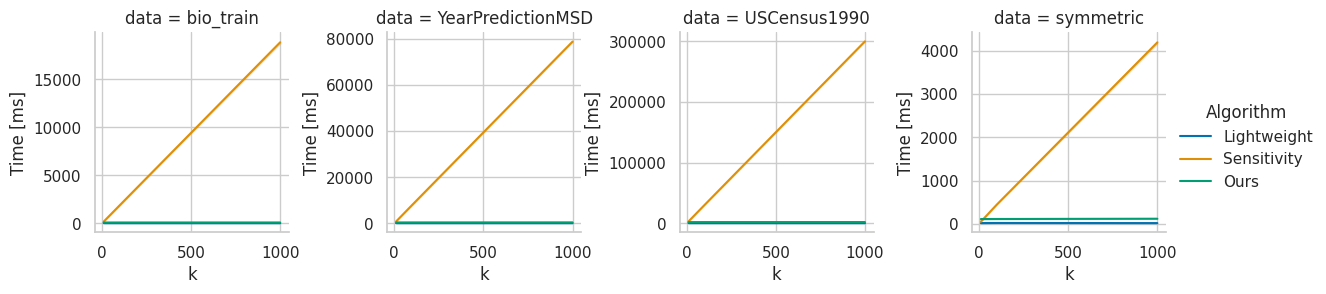

In [326]:
import seaborn as sns
sns.set_theme(style="whitegrid", palette="colorblind")

plot = sns.FacetGrid(data=df_full_time[(df_full_time["Size"] > 500)], hue="Algorithm", col="Dataset", sharey=False, sharex=False, margin_titles=False)

plot.map(sns.lineplot, "k", "Time", errorbar="se")
plot.add_legend(title="Algorithm")
plot.set_titles("data = {col_name}")
plot.set(ylabel="Time [ms]", xlabel="k")

plot.fig.subplots_adjust(top=0.9)

fig = plot.fig
fig.savefig("plots/coreset-time-plot.png", transparent=True, dpi=300)

In [538]:
print(df_full_time_rel.groupby(["Dataset", "Algorithm", "k"]).mean().round(decimals=1).unstack().to_latex())

\begin{tabular}{llrrr}
\toprule
          & {} & \multicolumn{3}{l}{Time} \\
          & k & 10   &  100  &   1000 \\
Dataset & Algorithm &      &       &        \\
\midrule
USCensus1990 & Lightweight &  7.3 &  69.4 &  670.2 \\
          & Ours &  1.5 &  14.1 &  136.3 \\
          & Sensitivity &  1.0 &   1.0 &    1.0 \\
YearPredictionMSD & Lightweight &  8.9 &  87.2 &  875.3 \\
          & Ours &  2.1 &  19.9 &  187.9 \\
          & Sensitivity &  1.0 &   1.0 &    1.0 \\
bio\_train & Lightweight &  6.4 &  63.0 &  642.8 \\
          & Ours &  2.1 &  19.6 &  192.6 \\
          & Sensitivity &  1.0 &   1.0 &    1.0 \\
symmetric & Lightweight &  2.4 &  17.6 &  174.8 \\
          & Ours &  0.5 &   3.8 &   33.7 \\
          & Sensitivity &  1.0 &   1.0 &    1.0 \\
\bottomrule
\end{tabular}



/tmp/ipykernel_68825/3363069526.py:1: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  print(df_full_time_rel.groupby(["Dataset", "Algorithm", "k"]).mean().round(decimals=1).unstack().to_latex())


# Clustering runtime table

In [540]:
# Load the table
df_bio_time = read_cluster_time_results("clustering-time-data/cluster-timings-bio_train.csv")
df_symmetric_time = read_cluster_time_results("clustering-time-data/cluster-timings-symmetric.csv")
df_song_time = read_cluster_time_results("clustering-time-data/cluster-timings-YearPredictionMSD.csv")
df_census_time = read_cluster_time_results("clustering-time-data/cluster-timings-USCensus1990.csv")
                        

df_full_time = pd.concat([df_bio_time, df_song_time, df_census_time, df_symmetric_time])

In [541]:
df_full_time

,Algorithm,Dataset,Centers,Time
0,Ours (biased),bio_train,10,71.240252
1,Ours (biased),bio_train,10,70.167258
2,Ours (biased),bio_train,10,71.798017
3,Ours (biased),bio_train,10,72.782360
4,Ours (biased),bio_train,10,73.816581
...,...,...,...,...
175,kmeans++,symmetric,5000,5109.738456
176,kmeans++,symmetric,5000,5106.102527
177,kmeans++,symmetric,5000,5185.911178
178,kmeans++,symmetric,5000,5362.898052


In [542]:
alg_names = ["Ours (biased)", "Ours (covariance)", "Ours", "kmeans++"]

df_list = [df_full_time[df_full_time["Algorithm"] == i] for i in alg_names]
df_means = [i.groupby(["Dataset", "Algorithm", "Centers"]).mean().to_numpy() for i in df_list]
rel_means = [df_means[3]/i for i in df_means]

df_list_rel = []
for (df, rel) in zip(df_list, rel_means):
    df = (df.groupby(["Dataset", "Algorithm", "Centers"]).mean())
    df["Time"] = rel
    df_list_rel.append(df)
    
df_full_time_rel = pd.concat(df_list_rel)
df_full_time_rel

Time
Dataset      Algorithm     Centers           
USCensus1990 Ours (biased) 10        0.464117
                           25        1.147098
                           50        2.243657
                           100       4.560447
                           250      11.036335
...                                       ...
symmetric    kmeans++      250       1.000000
                           500       1.000000
                           1000      1.000000
                           2500      1.000000
                           5000      1.000000

[144 rows x 1 columns]

In [544]:
print(df_full_time_rel.round(decimals=1).unstack().to_latex())

\begin{tabular}{llrrrrrrrrr}
\toprule
          & {} & \multicolumn{9}{l}{Time} \\
          & Centers & 10   & 25   & 50   &  100  &  250  &  500  &   1000 &   2500 &   5000 \\
Dataset & Algorithm &      &      &      &       &       &       &        &        &        \\
\midrule
USCensus1990 & Ours &  1.5 &  3.8 &  7.5 &  15.1 &  36.2 &  73.2 &  142.2 &  351.9 &  662.5 \\
          & Ours (biased) &  0.5 &  1.1 &  2.2 &   4.6 &  11.0 &  22.2 &   43.7 &  109.5 &  214.7 \\
          & Ours (covariance) &  0.2 &  0.5 &  1.1 &   2.2 &   5.2 &  10.7 &   21.0 &   54.7 &  117.4 \\
          & kmeans++ &  1.0 &  1.0 &  1.0 &   1.0 &   1.0 &   1.0 &    1.0 &    1.0 &    1.0 \\
YearPredictionMSD & Ours &  2.0 &  5.0 &  9.7 &  19.1 &  46.1 &  95.5 &  188.2 &  443.0 &  837.5 \\
          & Ours (biased) &  0.5 &  1.1 &  2.3 &   4.5 &  11.4 &  23.1 &   44.2 &  110.9 &  217.2 \\
          & Ours (covariance) &  0.2 &  0.4 &  0.8 &   1.5 &   4.0 &   8.2 &   15.5 &   40.0 &   82.4 \\
          & kme

/tmp/ipykernel_68825/3180183352.py:1: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  print(df_full_time_rel.round(decimals=1).unstack().to_latex())
